# SGI-3.12 — Spider-Man's vote, not his roads

**Marvel Superstars**, week 3. The week asked *who matters* and gave four answers — degree,
closeness, betweenness and PageRank — plus one habit for every number they produce: **compared to
what?**

**The question** (3.12's first opener). Who is the most surprising character in Marvel, by any
centrality, against the right null — and what do they bridge?

**The rule, fixed before looking.** A character is a surprise when their real value sits at least
three standard deviations from 200 shuffles that keep their links ($|z| \ge 3$). Among the
surprises, the *size* of the surprise is the **excess**, real − shuffled, in the measure's own
units. We rank by excess, not by $z$ or by the ratio real ÷ shuffled, because both of those explode
when the shuffled value is close to zero — section 3 meets the character this protects against.

Figures export to `Figures/Week3/`; every number quoted in the post lands in `stats.json`.

In [1]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import requests
from matplotlib.ticker import FuncFormatter

DATA = Path("../../Data/Week1")          # week 3 has no new release: same frozen snapshot
FIGDIR = Path("../../Figures/Week3")     # written straight to where the post reads them
FIGDIR.mkdir(parents=True, exist_ok=True)

DARK = {"figure.facecolor": "#161616", "axes.facecolor": "#161616",
        "axes.edgecolor": "#3a3a3a", "axes.labelcolor": "#8a8a8a",
        "text.color": "#e8e8e8", "xtick.color": "#8a8a8a", "ytick.color": "#8a8a8a",
        "grid.color": "#2e2e2e", "savefig.facecolor": "#161616", "figure.dpi": 130}
ABOVE_C, BELOW_C, FLAT_C, INK = "#e0913c", "#4f7fd4", "#4a4f5a", "#e8e8e8"   # site's --out, --in

B = 200             # shuffles per null, as 3.8 and 3.9 ask
Z = 3               # |z| >= 3 counts as a surprise: a convention, fixed before looking
ALPHA = 0.85        # PageRank's link-following probability, the course convention
STATS = {}          # every number quoted in the post lands here, then to stats.json


def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight", dpi=150)
    print(f"  wrote Figures/Week3/{name}.png")


def style(ax):
    ax.grid(alpha=.3, lw=.5)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


print(f"python {sys.version.split()[0]} | networkx {nx.__version__} | pandas {pd.__version__} | "
      f"matplotlib {plt.matplotlib.__version__}")

python 3.14.6 | networkx 3.6.1 | pandas 3.0.3 | matplotlib 3.11.0


## 1. Load: two views of one network

- **Undirected giant component — 277 characters, 1,421 links** — for closeness and betweenness.
  Both are built from distances, and distance is undefined between components. The same network as
  week 2 and exercise 3.8.
- **Directed, all 303 characters — 1,784 links** — for PageRank. A random walker follows links *out*
  of a page, so the arrows are the measure, and teleportation handles the pages nobody links to. The
  same network as exercise 3.7.

In [2]:
nodes = pd.read_csv(DATA / "week1_nodes.tsv", sep="\t", comment="#",
                    quoting=3)  # QUOTE_NONE: blurbs contain unescaped "quotes"
edges = pd.read_csv(DATA / "week1_edges.tsv", sep="\t", comment="#",
                    names=["source", "target"], quoting=3)

G = nx.DiGraph()
G.add_nodes_from(nodes.node_id)          # nodes first, or the 17 isolates silently vanish
G.add_edges_from(edges.itertuples(index=False, name=None))
U = G.to_undirected()
M = U.subgraph(max(nx.connected_components(U), key=len)).copy()

# display names: drop the generic Wikipedia qualifiers, keep the telling ones ("Human Torch (android)")
NAME = {u: re.sub(r" \((Marvel Comics|character|comics|Natasha Romanova)\)$", "", s)
        for u, s in zip(nodes.node_id, nodes.name)}
HERO, HERC, SPIDEY = "Black_Cat_(Marvel_Comics)", "Hercules_(Marvel_Comics)", "Spider-Man"

n, m, N = M.number_of_nodes(), M.number_of_edges(), G.number_of_nodes()
STATS.update(n=n, m=m, N=N, m_directed=G.number_of_edges())
print(f"  undirected giant component  n = {n}, m = {m}")
print(f"  directed, every character   n = {N}, m = {G.number_of_edges()}")
assert (n, m, N, G.number_of_edges()) == (277, 1421, 303, 1784)

  undirected giant component  n = 277, m = 1421
  directed, every character   n = 303, m = 1784


## 2. Four questions, four measures

| Measure | The question it answers | Definition |
|---|---|---|
| degree $k_i$ | **popularity** — how many links? | the number of neighbours |
| closeness $C_i$ | **reach** — how fast to everyone? | $C_i = \dfrac{n-1}{\sum_{j \ne i} d_{ij}}$, the inverse mean distance: $0.5$ means two steps from everyone on average |
| betweenness $b_i$ | **control** — whose paths run through you? | $b_i = \sum_{s \ne i \ne t} \dfrac{\sigma_{st}(i)}{\sigma_{st}}$, divided by the $(n-1)(n-2)/2$ pairs: the share of all shortest paths that pass through $i$ |
| PageRank $\mathrm{PR}_i$ | **prestige** — who links to you? | $\mathrm{PR}_i = \dfrac{1-\alpha}{n} + \alpha \sum_{j \to i} \dfrac{\mathrm{PR}_j}{k^{\text{out}}_j}$, the share of time a random walker spends on $i$ |

PageRank uses $\alpha = 0.85$ and a tolerance of $10^{-12}$ (networkx's default $10^{-6}$ moves the
fourth decimal).

In [3]:
k = pd.Series(dict(M.degree()))
kin, kout = pd.Series(dict(G.in_degree())), pd.Series(dict(G.out_degree()))
real = pd.DataFrame({"closeness": nx.closeness_centrality(M),
                     "betweenness": nx.betweenness_centrality(M)})


def pagerank(g):
    return pd.Series(nx.pagerank(g, alpha=ALPHA, tol=1e-12, max_iter=1000))


pr = pagerank(G)

measures = {"degree": k, "closeness": real.closeness, "betweenness": real.betweenness,
            "PageRank": pr}
top = pd.DataFrame({name: [NAME[u] for u in s.nlargest(5).index] for name, s in measures.items()},
                   index=pd.RangeIndex(1, 6, name="rank"))
rho = {"closeness": k.corr(real.closeness, method="spearman"),
       "betweenness": k.corr(real.betweenness, method="spearman"),
       "PageRank": kin.corr(pr, method="spearman")}            # PageRank against in-degree, all 303
STATS["rho"] = {name: round(r, 2) for name, r in rho.items()}
print("  rank correlation with degree:  " + ",  ".join(f"{name} {r:.2f}" for name, r in rho.items()))
top

  rank correlation with degree:  closeness 0.85,  betweenness 0.91,  PageRank 0.94


,degree,closeness,betweenness,PageRank
rank,,,,
1,Spider-Man,Spider-Man,Spider-Man,Spider-Man
2,Hulk,Hulk,Hulk,Hulk
3,Wolverine,Wolverine,Wolverine,Wolverine
4,Doctor Strange,Doctor Strange,Doctor Strange,Doctor Strange
5,Deadpool,Deadpool,Deadpool,Black Cat


**They mostly agree.** Spider-Man tops every list, and each measure's ranking tracks degree closely.
That agreement is the warning: a character with many links is bound to be close to everyone, sit on
many paths and collect many votes. A high score is not a finding until we know what the character's
degree alone would have given them.

## 3. Compared to what: one null per measure

Each measure is scored against a shuffle that keeps exactly what the measure would otherwise just be
restating:

- **Closeness and betweenness** — week 2's degree-preserving swap on the undirected giant component
  (A–B, C–D → A–D, C–B, ten swaps per link). Seeds 0–199, the same as exercise 3.8, so its
  $z$-scores reproduce here.
- **PageRank** — the directed version (`nx.directed_edge_swap`) on all 303 characters. It keeps every
  in-degree *and* every out-degree: what a character receives depends on how many pages link to them,
  and what each of those pages can give depends on how many other pages it links to. Seeds
  1000–1199, so the two nulls share no random numbers.

For every character and measure $x$, against the shuffles' mean $\mu$ and standard deviation
$\sigma$:

$$z = \frac{x - \mu}{\sigma} \qquad\qquad \text{excess} = x - \mu$$

$z$ says whether the difference is real; the excess says how big it is. Where a value never moves in
the shuffles ($\sigma = 0$ — the betweenness of a character with one link is 0 in every network), $z$
is undefined and the character is left out. The same loop also records degree assortativity for
section 5.

In [4]:
def swap(g, seed):
    # the week-2 shuffle, ten swaps per link; on a directed graph it keeps every in- and out-degree
    g = g.copy()
    e = g.number_of_edges()
    shuffle = nx.directed_edge_swap if g.is_directed() else nx.double_edge_swap
    shuffle(g, nswap=10 * e, max_tries=300 * e, seed=seed)
    return g


runs = {"closeness": {}, "betweenness": {}, "PageRank": {}}
r_null, spidey_nb = [], []                    # for section 5: assortativity, Spider-Man's neighbours
for s in range(B):
    g = swap(M, s)
    assert dict(g.degree()) == dict(k)                                      # degrees kept
    runs["closeness"][s] = nx.closeness_centrality(g)
    runs["betweenness"][s] = nx.betweenness_centrality(g)
    r_null.append(nx.degree_assortativity_coefficient(g))
    spidey_nb.append(set(g[SPIDEY]))
    d = swap(G, 1000 + s)
    assert dict(d.in_degree()) == dict(kin) and dict(d.out_degree()) == dict(kout)
    runs["PageRank"][s] = pagerank(d)
runs = {name: pd.DataFrame(v) for name, v in runs.items()}   # one row per character, one column per shuffle


def compare(x, null, degree):
    mu, sd = null.mean(axis=1), null.std(axis=1, ddof=1)
    return pd.DataFrame({"k": degree, "real": x, "shuffled": mu, "real / shuffled": x / mu,
                         "z": (x - mu) / sd.replace(0, np.nan), "excess": x - mu})


T = {"betweenness": compare(real.betweenness, runs["betweenness"], k),
     "closeness": compare(real.closeness, runs["closeness"], k),
     "PageRank": compare(pr, runs["PageRank"], kin)}            # PageRank's "k" is the in-degree
print(f"  {B} undirected + {B} directed shuffles; every degree (in- and out-degree) kept in each")
print("  z undefined for " + ", ".join(f"{name} {t.z.isna().sum()}" for name, t in T.items())
      + f"  (the {(k == 1).sum()} one-link characters' betweenness is 0 in every network)")

  200 undirected + 200 directed shuffles; every degree (in- and out-degree) kept in each
  z undefined for betweenness 18, closeness 0, PageRank 0  (the 18 one-link characters' betweenness is 0 in every network)


In [5]:
def surprises(t):
    s = t[t.z.abs() >= Z]
    return s.loc[s.excess.abs().sort_values(ascending=False).index]


S = pd.concat({name: surprises(t) for name, t in T.items()}, names=["measure", "character"])
STATS["surprises"] = {name: [[NAME[u], int(r.k), round(r.real, 4), round(r.shuffled, 4),
                              round(r["real / shuffled"], 2), round(r.z, 1), round(r.excess, 4)]
                             for u, r in surprises(t).iterrows()] for name, t in T.items()}
two = S.index.get_level_values("character").value_counts()
STATS["on_two_measures"] = [NAME[u] for u in two[two > 1].index]
sb = T["betweenness"].loc[SPIDEY]                       # the top scorer is no surprise: it is his degree
STATS["spidey_b"] = {"k": int(sb.k), "real": round(sb.real, 3), "shuffled": round(sb.shuffled, 3),
                     "z": round(sb.z, 1)}
print(f"  Spider-Man: betweenness {sb.real:.3f} against {sb.shuffled:.3f} in the shuffles, z = {sb.z:+.1f}")
print("  surprising on more than one measure: " + ", ".join(STATS["on_two_measures"]))
(S.rename(index=NAME, level="character")
  .style.format({"real": "{:.4f}", "shuffled": "{:.4f}", "real / shuffled": "{:.2f}×",
                 "z": "{:+.1f}", "excess": "{:+.4f}"}))

  Spider-Man: betweenness 0.235 against 0.231 in the shuffles, z = +0.5
  surprising on more than one measure: Black Cat


**Twenty-two characters, twenty-three surprises — and one name on two lists.**

- **Betweenness: nine, of two kinds.** Hercules, Black Widow and U.S. Agent carry about twice the
  share of shortest paths their degree predicts (+1.3 to +1.9 percentage points): the **brokers**.
  Black Cat carries a third of hers (0.36×), the only character *below* her prediction. The other five
  — Rockman, Nightmask, Turbo, Guardsman, Genis-Vell — are small "only doors", each the sole neighbour
  of a one-link character. They top the $z$ and ratio columns; the excess puts them below the brokers.
- **Closeness: six, all *further* from everyone than their degree predicts.** Nobody is surprisingly
  close. Closeness averages 276 distances that the degrees mostly settle, so even the surprises sit
  at 0.83–0.89× their shuffled value. Four are WWII-era heroes; section 5 asks why.
- **PageRank: eight, all *above* their prediction.** The next cell shows where it comes from.

In [6]:
# 1. Rockman: his whole betweenness is one leaf's paths
rock = "Rockman_(character)"
leaf = [u for u in M[rock] if M.degree(u) == 1]
assert len(leaf) == 1 and np.isclose(real.betweenness[rock], 2 / (n - 1))
t = T["betweenness"].loc[rock]
STATS["rockman"] = {"leaf": NAME[leaf[0]], "k": int(t.k), "b": round(t.real, 4),
                    "ratio": round(t["real / shuffled"], 1), "z": round(t.z, 1),
                    "excess": round(t.excess, 4), "hercules_excess": round(T["betweenness"].excess[HERC], 4)}
print(f"  Rockman: 2 links, one of them to {NAME[leaf[0]]} (1 link). His betweenness {t.real:.4f} is exactly")
print(f"  2/(n-1) = {2 / (n - 1):.4f}: the {n - 2} paths from that one character to everyone else.")
print(f"  {t['real / shuffled']:.0f}× his shuffled value and z = {t.z:+.1f}, yet an excess of only "
      f"{t.excess:+.4f}, against Hercules's {T['betweenness'].excess[HERC]:+.4f}.")

# 2. PageRank: who gives each surprise their score
spidey_list = set(G.successors(SPIDEY))
rows = []
for u in surprises(T["PageRank"]).index:
    votes = pd.Series({j: ALPHA * pr[j] / kout[j] for j in G.predecessors(u)})
    j = votes.idxmax()
    rows.append({"character": NAME[u], "in-links": kin[u], "biggest vote from": NAME[j],
                 "its out-links": kout[j], "share of PageRank": votes[j] / pr[u]})
donors = pd.DataFrame(rows).set_index("character")
STATS["pagerank_donors"] = {"spidey_out": int(kout[SPIDEY]),
                            "spidey_vote": round(ALPHA * pr[SPIDEY] / kout[SPIDEY], 4),
                            "surprises": len(donors),
                            "from_spidey": int((donors["biggest vote from"] == "Spider-Man").sum()),
                            "table": [[c, int(r["in-links"]), r["biggest vote from"],
                                       int(r["its out-links"]), round(r["share of PageRank"], 2)]
                                      for c, r in donors.iterrows()]}
print(f"\n  Spider-Man links to {kout[SPIDEY]} characters, so each of those links carries "
      f"alpha * PR / 9 = {ALPHA * pr[SPIDEY] / kout[SPIDEY]:.4f}")
donors.style.format({"share of PageRank": "{:.0%}"})

  Rockman: 2 links, one of them to The Witness (1 link). His betweenness 0.0072 is exactly
  2/(n-1) = 0.0072: the 275 paths from that one character to everyone else.
  73× his shuffled value and z = +13.4, yet an excess of only +0.0071, against Hercules's +0.0192.

  Spider-Man links to 9 characters, so each of those links carries alpha * PR / 9 = 0.0047


,in-links,biggest vote from,its out-links,share of PageRank
character,,,,
Black Cat,21,Spider-Man,9,27%
Mayday Parker,14,Spider-Man,9,33%
Venom,17,Spider-Man,9,35%
Spider-Man Noir,7,Spider-Man,9,53%
Spider-UK,2,Spider-Man,9,77%
Scarlet Spider,8,Spider-Man,9,55%
Marvel Boy (Robert Grayson),2,Quasar,3,74%
Devil Hulk,1,Hulk,10,82%


**Rockman is certain, not big.** His only other neighbour, The Witness, has one link, so all 275 of
The Witness's shortest paths run through him — his entire betweenness, exactly $2/(n-1)$. In the
shuffles The Witness is usually attached to a hub instead, so Rockman's baseline is almost zero, and
dividing by almost zero is what blows up his $z$ and his ratio.

**Every PageRank surprise holds one vote from a page with few out-links.** Six of the eight are on
Spider-Man's nine-link list, and his single link is 27–77% of their PageRank; Marvel Boy's comes from
Quasar (3 out-links), Devil Hulk's from the Hulk (10). The directed shuffle keeps every character's
in-links and every page's out-links — but not *which* page links to whom, and in PageRank that is the
whole point.

  wrote Figures/Week3/fig1_surprise_map.png


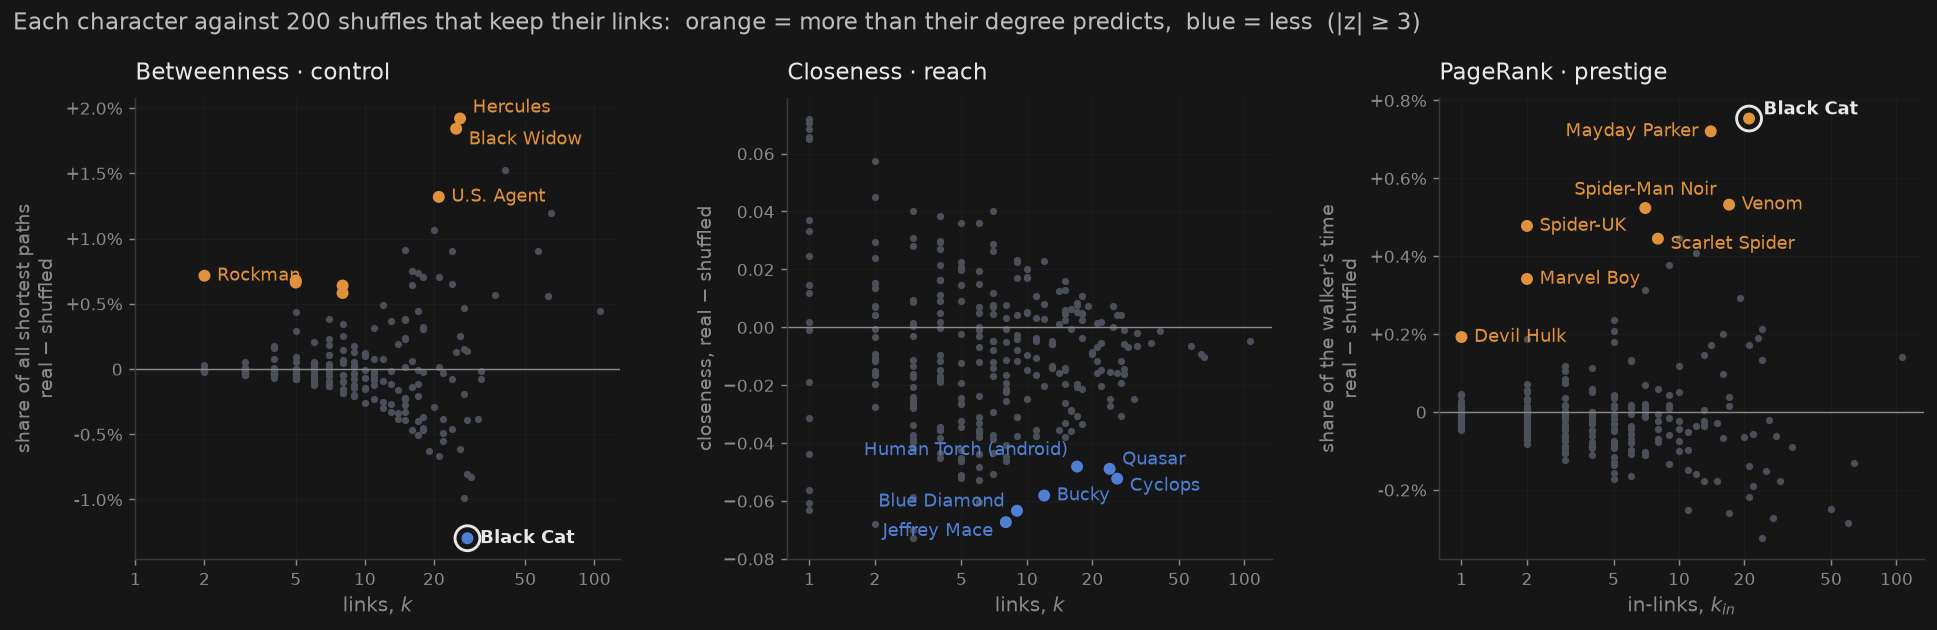

In [7]:
PANELS = [("betweenness", "Betweenness · control", "links, $k$",
           "share of all shortest paths\nreal − shuffled"),
          ("closeness", "Closeness · reach", "links, $k$", "closeness, real − shuffled"),
          ("PageRank", "PageRank · prestige", "in-links, $k_{in}$",
           "share of the walker's time\nreal − shuffled")]
BW = "Black_Widow_(Natasha_Romanova)"
LABELS = {"betweenness": [HERC, BW, "U.S._Agent", rock, HERO],     # the doors beside Rockman stay unnamed
          "closeness": list(surprises(T["closeness"]).index),
          "PageRank": list(surprises(T["PageRank"]).index)}
SHORT = {"Marvel Boy (Robert Grayson)": "Marvel Boy"}
by_name = {NAME[u]: u for u in M}
# the post's versus panel: every character named in a panel, with that panel's numbers
STATS["versus"] = {name: {NAME[u]: {"k": int(T[name].k[u]), "real": round(T[name].real[u], 4),
                                    "shuffled": round(T[name].shuffled[u], 4),
                                    "excess": round(T[name].excess[u], 4), "z": round(T[name].z[u], 1)}
                          for u in LABELS[name]} for name in T}
NUDGE = {("betweenness", HERC): (7, 6), ("betweenness", BW): (7, -6),          # (dx, dy) in points
         ("closeness", by_name["Jeffrey Mace"]): (-7, -5), ("closeness", by_name["Blue Diamond"]): (-7, 5),
         ("closeness", by_name["Human Torch (android)"]): (-5, 9), ("closeness", by_name["Quasar"]): (7, 5),
         ("closeness", by_name["Cyclops"]): (7, -4),
         ("PageRank", "Mayday_Parker"): (-7, 0), ("PageRank", "Spider-Man_Noir"): (0, 10),
         ("PageRank", "Scarlet_Spider"): (7, -3), ("PageRank", HERO): (8, 5)}
pct = FuncFormatter(lambda v, _: f"{100 * v:+.1f}%".replace("+0.0%", "0"))

with plt.rc_context(DARK):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.9))
    for ax, (name, title, xlabel, ylabel) in zip(axs, PANELS):
        t = T[name][T[name].z.notna() & (T[name].k > 0)]
        hot = t[t.z.abs() >= Z]
        ax.axhline(0, color="#8a8a8a", lw=.8)
        ax.scatter(t.k, t.excess, s=16, color=FLAT_C, lw=0)
        ax.scatter(hot.k, hot.excess, s=44, lw=0, zorder=3,
                   color=[ABOVE_C if z > 0 else BELOW_C for z in hot.z])
        if HERO in hot.index:
            ax.scatter(t.k[HERO], t.excess[HERO], s=190, facecolors="none", edgecolors=INK,
                       lw=1.6, zorder=4)
        for u in LABELS[name]:
            dx, dy = NUDGE.get((name, u), (7, 0))
            ax.annotate(SHORT.get(NAME[u], NAME[u]), (t.k[u], t.excess[u]), xytext=(dx, dy),
                        textcoords="offset points", va="center", fontsize=10,
                        ha="center" if dx == 0 else ("left" if dx > 0 else "right"),
                        fontweight="bold" if u == HERO else "normal",
                        color=INK if u == HERO else (ABOVE_C if t.z[u] > 0 else BELOW_C))
        ax.set_xscale("log")
        ax.set_xticks([1, 2, 5, 10, 20, 50, 100])
        ax.set_xticks([], minor=True)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        if name != "closeness":
            ax.yaxis.set_major_formatter(pct)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=10.5)
        ax.set_title(title, fontsize=13, color=INK, loc="left", pad=10)
        ax.tick_params(labelsize=9.5)
        style(ax)
    fig.suptitle("Each character against 200 shuffles that keep their links:  orange = more than "
                 "their degree predicts,  blue = less  (|z| ≥ 3)",
                 x=.01, ha="left", fontsize=12.5, color="#bdbdbd")
    fig.tight_layout(w_pad=2.5)
    save(fig, "fig1_surprise_map")
    plt.show()

**How to read it.** One dot per character. Height is the excess: how much more (or less) of the
measure a character has than the 200 shuffles give someone with their links. Coloured dots pass
$|z| \ge 3$. Rockman's $z$ of +13.4 would tower over everyone in a $z$-plot; by size, he sits below
the brokers. Black Cat, ringed, is below the line in one panel and at the top of another.

The named characters' numbers also go to `STATS["versus"]`, and the post embeds a copy of it for
its versus panel: pick two, and it shows who their links say *should* win, who *does* win, and who
is the bigger surprise. The final check below makes sure that copy still matches.

## 4. Black Cat: Spider-Man's vote, not his roads

Black Cat is the only character surprising on two measures, in opposite directions. Each measure
has a mechanism we can look at directly:

- **Betweenness counts the paths that need you.** Remove the character and measure how far apart
  their friends become. Friends that are still one or two steps apart had routes that never needed
  them; friends three or more steps apart were connected through them.
- **PageRank counts votes.** A character's PageRank splits exactly into the vote of every page that
  links to them, $\alpha\,\mathrm{PR}_j / k^{\text{out}}_j$, plus the walker's random jumps (the
  teleport $(1-\alpha)/n$, and the pages with no out-links, whose share networkx spreads evenly).

In [8]:
def friend_distances(ego):
    # share of the ego's friend pairs at distance 1, 2 and 3+ once the ego is removed
    friends = sorted(M[ego])
    rest = M.copy()
    rest.remove_node(ego)
    d = []
    for i, a in enumerate(friends):
        reach = nx.single_source_shortest_path_length(rest, a)
        d += [reach.get(b, np.inf) for b in friends[i + 1:]]
    d = np.array(d)
    return {"1": (d == 1).mean(), "2": (d == 2).mean(), "3+": (d >= 3).mean()}


gap = pd.DataFrame({NAME[u]: friend_distances(u) for u in (HERC, HERO)}).T

votes = pd.Series({j: ALPHA * pr[j] / kout[j] for j in G.predecessors(HERO)}).sort_values(ascending=False)
dangling = pr[kout == 0].sum()
jumps = (1 - ALPHA) / N + ALPHA * dangling / N
assert np.isclose(votes.sum() + jumps, pr[HERO], rtol=1e-9)        # the split is exact
share = votes / pr[HERO]
family = [j for j in share.index if j == SPIDEY or j in spidey_list]    # Spider-Man and his nine

shared = len(set(M[HERO]) & set(M[SPIDEY]))
STATS["hero"] = {
    "k": int(k[HERO]), "kin": int(kin[HERO]), "kout": int(kout[HERO]), "shared_with_spidey": shared,
    "b": round(real.betweenness[HERO], 4), "b_shuffled": round(T["betweenness"].shuffled[HERO], 4),
    "b_ratio": round(T["betweenness"]["real / shuffled"][HERO], 2), "b_z": round(T["betweenness"].z[HERO], 1),
    "pr": round(pr[HERO], 4), "pr_shuffled": round(T["PageRank"].shuffled[HERO], 4),
    "pr_ratio": round(T["PageRank"]["real / shuffled"][HERO], 2), "pr_z": round(T["PageRank"].z[HERO], 1),
    "pr_rank": int(pr.rank(ascending=False)[HERO]), "kin_rank": int(kin.rank(ascending=False, method="min")[HERO]),
    "spidey_share": round(share[SPIDEY], 2), "next_share": round(share.drop(SPIDEY).max(), 2),
    "next_donor": NAME[share.drop(SPIDEY).idxmax()], "jumps_share": round(jumps / pr[HERO], 2),
    "family_donors": [NAME[j] for j in family], "family_share": round(share[family].sum(), 2),
    "others_share": round(share.drop(family).sum(), 2), "others_n": len(share) - len(family)}
STATS["friend_gap"] = {name: {d: round(v, 2) for d, v in row.items()} for name, row in gap.iterrows()}

print(f"  Black Cat: {k[HERO]} links, {shared} of them also Spider-Man's neighbours")
print(f"  PageRank {pr[HERO]:.4f} (rank {STATS['hero']['pr_rank']}; in-degree rank "
      f"{STATS['hero']['kin_rank']}): Spider-Man's one link = {share[SPIDEY]:.0%} of it, "
      f"the next biggest vote {share.drop(SPIDEY).max():.0%}, random jumps {jumps / pr[HERO]:.0%}")
print(f"  Spider-Man plus the characters on his nine-link list: {share[family].sum():.0%} of her PageRank "
      f"({', '.join(NAME[j] for j in family)}); her other {len(share) - len(family)} in-links "
      f"{share.drop(family).sum():.0%}")
gap.style.format("{:.0%}").set_caption("share of friend pairs at each distance, once the character is removed")

  Black Cat: 28 links, 24 of them also Spider-Man's neighbours
  PageRank 0.0176 (rank 5; in-degree rank 17): Spider-Man's one link = 27% of it, the next biggest vote 14%, random jumps 3%
  Spider-Man plus the characters on his nine-link list: 73% of her PageRank (Spider-Man, Scarlet Spider, Silk, Spider-Man Noir, Mayday Parker, Spider-Woman (Gwen Stacy), Venom); her other 14 in-links 24%


,1,2,3+
Hercules,13%,45%,43%
Black Cat,25%,72%,4%


  wrote Figures/Week3/fig2_black_cat.png


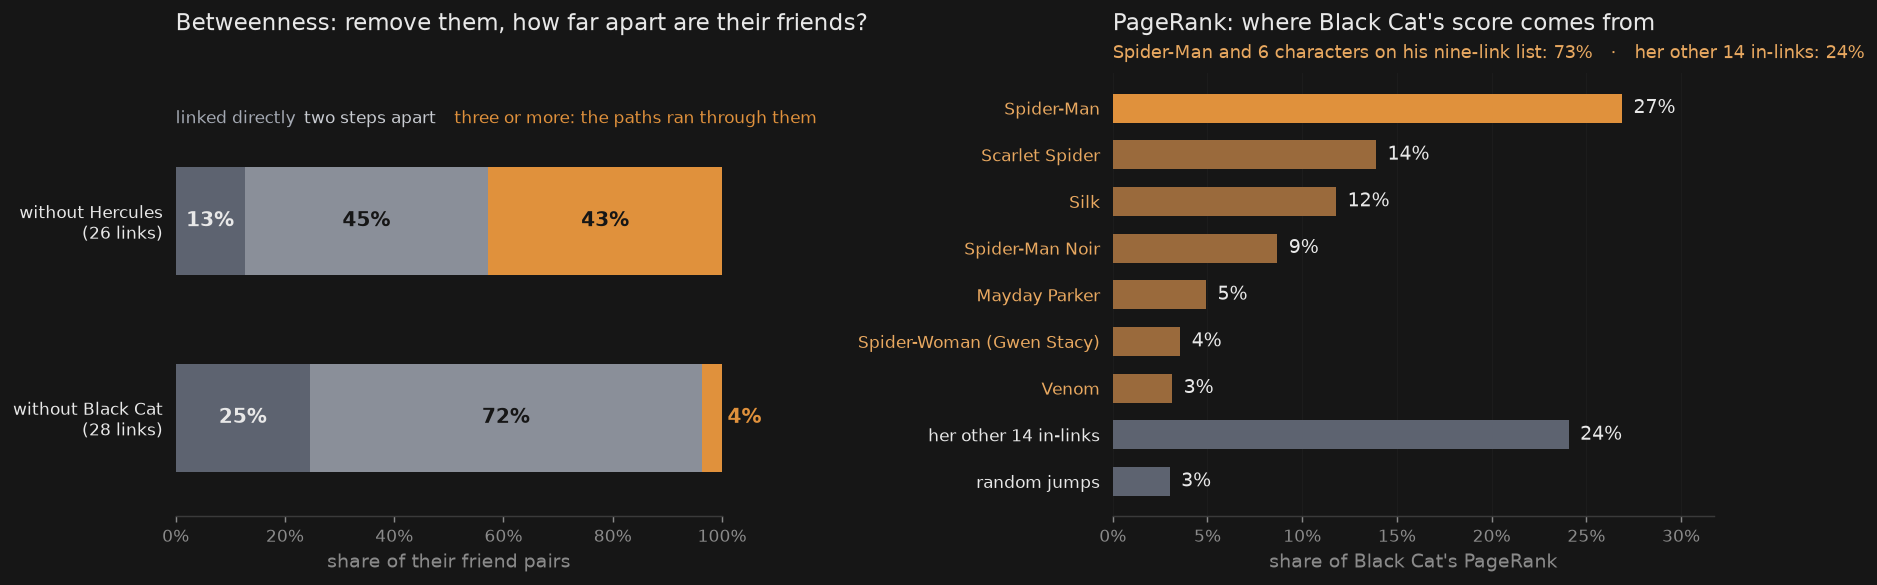

In [9]:
others = len(share) - len(family)
bars = pd.concat([share[family].rename(index=NAME),                  # Spider-Man first, then his list
                  pd.Series({f"her other {others} in-links": share.drop(family).sum(),
                             "random jumps": jumps / pr[HERO]})])

with plt.rc_context(DARK):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.1]})

    # left: how far apart the friends are, without the character
    SEG = [("1", "linked directly", "#5d6370", "#a4a9b3"), ("2", "two steps apart", "#8a8f99", "#c9ccd2"),
           ("3+", "three or more: the paths ran through them", ABOVE_C, ABOVE_C)]   # bar, legend text
    ys = [1, 0]
    for y, (who, row) in zip(ys, gap.iterrows()):
        left = 0
        for key, label, colour, _ in SEG:
            a1.barh(y, row[key], left=left, height=.55, color=colour)
            if row[key] >= .06:
                a1.text(left + row[key] / 2, y, f"{row[key]:.0%}", ha="center", va="center",
                        fontsize=11, color="#161616" if key != "1" else INK, fontweight="bold")
            else:                                         # too thin to hold its label: put it outside
                a1.text(1.01, y, f"{row[key]:.0%}", ha="left", va="center", fontsize=11,
                        color=colour, fontweight="bold")
            left += row[key]
    a1.set_yticks(ys)
    a1.set_yticklabels([f"without {w}\n({k[u]} links)" for w, u in zip(gap.index, (HERC, HERO))],
                       fontsize=11, color=INK)
    a1.set_xlim(0, 1)
    a1.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    a1.set_xlabel("share of their friend pairs", fontsize=10.5)
    for x, (key, label, _, text_colour) in zip((0, .235, .51), SEG):
        a1.text(x, 1.52, label, fontsize=9.5, color=text_colour, ha="left", va="center")
    a1.set_ylim(-.5, 1.75)
    a1.set_title("Betweenness: remove them, how far apart are their friends?", fontsize=12.5,
                 color=INK, loc="left", pad=24)
    for s in ("top", "right", "left"):
        a1.spines[s].set_visible(False)
    a1.tick_params(left=False, labelsize=9.5)

    # right: where Black Cat's PageRank comes from
    yb = np.arange(len(bars))[::-1]
    listed = {NAME[j] for j in spidey_list}
    colours = [ABOVE_C if c == "Spider-Man" else "#9a6a3c" if c in listed else "#5d6370"
               for c in bars.index]
    a2.barh(yb, bars.values, height=.62, color=colours)
    for y, v in zip(yb, bars.values):
        a2.text(v + .006, y, f"{v:.0%}", va="center", fontsize=10.5, color=INK)
    a2.set_yticks(yb)
    a2.set_yticklabels(bars.index, fontsize=10.5)
    for tick, c in zip(a2.get_yticklabels(), colours):
        tick.set_color("#e8a860" if c != "#5d6370" else INK)
    a2.text(0, 1.025, f"Spider-Man and {len(family) - 1} characters on his nine-link list: "
            f"{share[family].sum():.0%}   ·   her other {others} in-links: {share.drop(family).sum():.0%}",
            transform=a2.transAxes, ha="left", va="bottom", fontsize=10, color="#e8a860")
    a2.set_xlim(0, bars.max() * 1.18)
    a2.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    a2.set_xlabel("share of Black Cat's PageRank", fontsize=10.5)
    a2.set_title("PageRank: where Black Cat's score comes from", fontsize=12.5, color=INK,
                 loc="left", pad=24)
    a2.grid(alpha=.3, lw=.5, axis="x")
    a2.set_axisbelow(True)
    for s in ("top", "right", "left"):
        a2.spines[s].set_visible(False)
    a2.tick_params(left=False, labelsize=9.5)

    fig.tight_layout(w_pad=4)
    save(fig, "fig2_black_cat")
    plt.show()

**Two verdicts, one cause.**

- **No roads.** 24 of Black Cat's 28 neighbours are also Spider-Man's, so her friends reach each
  other through him. Remove her and only 4% of her friend pairs end up three or more steps apart,
  against 43% for Hercules. Hardly any shortest path needs her: she carries 0.71% of them, against
  2.01% in the shuffles.
- **The vote.** Spider-Man's single link is 27% of her PageRank, twice the next-biggest vote — and
  the next votes come from his list too. Spider-Man and six of the characters he links to give her
  73% of her score, from 7 of her 21 in-links. She is 17th by in-degree and 5th by PageRank.

His neighbourhood makes her redundant as a road; his page makes her prestigious.

## 5. Why the far ones are far: mixing

Every closeness surprise is *further* from everyone than their degree predicts. Two mixing
measurements from Part 7 can say why. **Degree assortativity** $r$ asks whether hubs link to hubs;
**homophily** asks whether like links to like on an attribute — here the decade of a character's
first comic-book appearance.

The decade comes from each character's live Wikipedia infobox (`debutyr`, else the earliest year in
`debut`; 7 API calls of 50 titles). Redirects are **not** followed: a page that has since become a
redirect counts as unknown, or the Strikeforce: Morituri members would inherit their team page's debut.
The null for homophily freezes the links and shuffles the decade labels across characters (Goodies,
*Shuffling the labels instead of the links*) — plainly, and again only within five degree bins, because
early characters are also the hubs.

In [10]:
r_real = nx.degree_assortativity_coefficient(M)
r_mu, r_sd = np.mean(r_null), np.std(r_null, ddof=1)

API = "https://en.wikipedia.org/w/api.php"
HEAD = {"User-Agent": "DTU-02805-coursework/1.0 (student notebook)"}
wikitext = {}
for i in range(0, len(nodes), 50):                          # the API takes 50 titles per call
    q = requests.get(API, headers=HEAD, timeout=30, params={
        "action": "query", "prop": "revisions", "rvprop": "content", "rvslots": "main",
        "titles": "|".join(nodes.node_id[i:i + 50]), "format": "json", "formatversion": 2})
    q.raise_for_status()
    wikitext |= {p["title"].replace(" ", "_"): p["revisions"][0]["slots"]["main"]["content"]
                 for p in q.json()["query"]["pages"]}


def debut_year(src):
    src = re.sub(r"\[\[(?:[^|\]]*\|)?([^\]]*)\]\]", r"\1", src)          # [[a|b]] -> b
    if hit := re.search(r"\|\s*debutyr\s*=\s*((?:19|20)\d\d)", src):
        return int(hit.group(1))
    hit = re.search(r"\|\s*debut\s*=(.*?)\n\s*[|}]", src, re.S)
    years = re.findall(r"\([^()]*?((?:19|20)\d\d)[^()]*\)", hit.group(1)) if hit else []
    return min(map(int, years)) if years else None


year = pd.Series({u: debut_year(wikitext[u]) for u in nodes.node_id})
decade = (year.dropna() // 10 * 10).astype(int)
H = M.subgraph(decade.index.intersection(list(M))).copy()           # giant component, decade known
nx.set_node_attributes(H, decade.to_dict(), "decade")
h_real = nx.attribute_assortativity_coefficient(H, "decade")
labels = decade[list(H)]
rng = np.random.default_rng(3012)                                    # its own stream: no shared seeds


def label_null(groups):
    out = []
    for _ in range(B):                                   # freeze the links, permute the labels
        perm = labels.groupby(groups).transform(lambda s: rng.permutation(s.values))
        nx.set_node_attributes(H, perm.to_dict(), "shuffled")
        out.append(nx.attribute_assortativity_coefficient(H, "shuffled"))
    return np.array(out)


kh = pd.Series(dict(H.degree()))[labels.index]
plain = label_null(np.zeros(len(labels)))
strat = label_null(pd.qcut(kh.rank(method="first"), 5, labels=False))

far = list(surprises(T["closeness"]).index)
old = {1930, 1940}
ww2 = [u for u in far if year[u] < 1950]
ww2_nb = [v for u in ww2 for v in M[u] if v in decade.index]

# is missing Spider-Man the reason? condition each far character's shuffles on that one link
linked = pd.DataFrame({s: {u: u in spidey_nb[s] for u in far} for s in range(B)})
cl = runs["closeness"].loc[far]
hub = pd.DataFrame({"debut": year[far].astype(int), "k": k[far],
                    "real": real.closeness[far], "shuffled": cl.mean(axis=1),
                    "shuffles linked to Spider-Man": linked.mean(axis=1),
                    "shuffled, not linked": cl.where(~linked).mean(axis=1)})
hub["gap explained by the missing link"] = ((hub.shuffled - hub["shuffled, not linked"])
                                            / (hub.shuffled - hub.real))
STATS["mixing"] = {
    "r": round(r_real, 3), "r_null": [round(r_mu, 3), round(r_sd, 3)], "r_z": round((r_real - r_mu) / r_sd, 1),
    "decade_known": len(decade), "decade_n": H.number_of_nodes(), "decade_m": H.number_of_edges(),
    "homophily": round(h_real, 3),
    "plain": [round(plain.mean(), 3), round(plain.std(ddof=1), 3), round((h_real - plain.mean()) / plain.std(ddof=1), 1)],
    "strat": [round(strat.mean(), 3), round(strat.std(ddof=1), 3), round((h_real - strat.mean()) / strat.std(ddof=1), 1)],
    "far": [[NAME[u], int(year[u]), SPIDEY in M[u]] for u in far],
    "ww2": [NAME[u] for u in ww2],
    "ww2_old_share": round(np.mean([decade[v] in old for v in ww2_nb]), 2),
    "all_old_share": round(decade.isin(old).mean(), 2),
    "hub_link_explains": [round(hub["gap explained by the missing link"].min(), 2),
                          round(hub["gap explained by the missing link"].max(), 2)],
    "hub_link_prob": [round(hub["shuffles linked to Spider-Man"].min(), 2),
                      round(hub["shuffles linked to Spider-Man"].max(), 2)],
    "mean_degree_by_decade": {int(d): round(v, 1) for d, v in kh.groupby(labels).mean().items()}}

x = STATS["mixing"]
print(f"  degree assortativity r = {r_real:+.3f}; shuffles {r_mu:+.3f} ± {r_sd:.3f}, z = {x['r_z']:+.1f}")
print(f"  first-appearance year found for {len(decade)} of {N} characters "
      f"({H.number_of_nodes()} in the giant component, {H.number_of_edges()} links between them)")
print(f"  decade homophily {h_real:+.3f};  shuffle all labels {x['plain'][0]:+.3f} ± {x['plain'][1]:.3f}, "
      f"z = {x['plain'][2]:+.1f};  within degree bins z = {x['strat'][2]:+.1f}")
print(f"  the {len(ww2)} WWII-era closeness surprises: {x['ww2_old_share']:.0%} of their neighbours debuted "
      f"in the 1930s-40s, against {x['all_old_share']:.0%} of all characters")
print(f"  linked to Spider-Man: {sum(s_ for *_, s_ in x['far'])} of the {len(far)} closeness surprises")
(hub.rename(index=NAME).style.format({"real": "{:.3f}", "shuffled": "{:.3f}", "shuffled, not linked": "{:.3f}",
                                      "shuffles linked to Spider-Man": "{:.0%}",
                                      "gap explained by the missing link": "{:.0%}"}))

  degree assortativity r = -0.105; shuffles -0.121 ± 0.010, z = +1.5
  first-appearance year found for 284 of 303 characters (268 in the giant component, 1394 links between them)
  decade homophily +0.072;  shuffle all labels -0.007 ± 0.011, z = +7.1;  within degree bins z = +6.9
  the 4 WWII-era closeness surprises: 52% of their neighbours debuted in the 1930s-40s, against 8% of all characters
  linked to Spider-Man: 0 of the 6 closeness surprises


,debut,k,real,shuffled,shuffles linked to Spider-Man,"shuffled, not linked",gap explained by the missing link
Jeffrey Mace,1941,8,0.328,0.395,38%,0.385,16%
Blue Diamond,1941,9,0.337,0.400,42%,0.389,18%
Bucky,1941,12,0.359,0.417,53%,0.404,22%
Cyclops,1963,26,0.411,0.463,68%,0.452,21%
Quasar,1979,24,0.408,0.457,67%,0.447,22%
Human Torch (android),1939,17,0.388,0.436,62%,0.422,28%


- **Degree mixing is structural.** $r = -0.105$ against $-0.121 \pm 0.010$ in the shuffles
  ($z = +1.5$). Hubs link to small characters because there are not enough hubs to go around, as
  Part 7 says — not a finding about Marvel.
- **Decade homophily is real.** Characters link to their own era: $+0.072$ against
  $-0.007 \pm 0.011$ with the labels shuffled ($z = +7.1$), and still $z = +6.9$ shuffling only within
  degree bins, so it is not just the early characters being hubs.
- **It explains four of the six far characters.** Jeffrey Mace, Blue Diamond, Bucky and the android
  Human Torch debuted in 1939–41, and 52% of their neighbours come from the 1930s–40s, against 8% of
  all characters. They live in a closed wartime corner of the network.
- **Missing Spider-Man is not the reason.** None of the six links to him, where the shuffles link
  them 38–68% of the time. But even in the shuffles where they miss him too, their closeness drops
  only 16–28% of the way to the real value; the rest is where their neighbours sit. For Cyclops
  (1963) and Quasar (1979) the decade cannot say where that is — their groups are a question for
  week 4's communities.

## 6. What we found

**Marvel's most surprising character is Black Cat** — the only one surprising on two measures, in
opposite directions. She has 1.75× the PageRank her in- and out-links predict ($z = +3.8$, the
largest PageRank excess of anyone) and 0.36× the betweenness her degree predicts ($z = -3.1$). Both
come from Spider-Man: **his vote, not his roads.**

**Spider-Man's vote is the currency of prestige.** Six of the eight PageRank surprises hold one of his
nine out-links; the other two hold a vote from a page with nearly as few.

**Brokers are real but modest.** Hercules, Black Widow and U.S. Agent carry about twice the paths
their degree predicts. The biggest $z$ in the network, Rockman's +13.4, is one leaf's paths.

**Reach is hard to be surprising at**, and the six who are all fall short — four of them in a
wartime corner of their own era.

**Choices we made.**

- *$|z| \ge 3$ for whether, excess for how much.* Ranking by $z$ or by real ÷ shuffled crowns
  Rockman (73×): a near-zero baseline blows both up.
- *One null per measure.* Undirected swaps for the path measures; directed swaps that keep in- and
  out-degree for PageRank, which lives on the arrows.
- *Undirected giant component for paths, all 303 characters for PageRank* — the networks of
  exercises 3.3–3.8 and 3.7.
- *200 shuffles each; seeds 0–199 and 1000–1199.* The first set reproduces 3.8's $z$-scores exactly.
- *Debut decade from the live infoboxes, redirects not followed* — 284 of 303 found; homophily
  tested on the 268 in the giant component.

**What we cannot conclude.** That Black Cat matters less in the comics: this is a map of how
Wikipedia's editors link articles (week 1). That her prestige is undeserved: PageRank is built to
reward exactly this kind of vote. Or why Cyclops and Quasar are far: the decade cannot see their
groups.

## 7. Every number, pinned

`stats.json` is the single source for the post. The regression check pins the numbers that come from
the frozen data and the fixed seeds, so a change in the snapshot, the loading or the networkx version
fails loudly instead of leaving stale prose on the site. The decade numbers are pinned too, even
though they come from live Wikipedia: if an infobox changes, the check should say so. Last, it
checks that the copy of `STATS["versus"]` embedded in the post is still identical.

In [11]:
Path("stats.json").write_text(json.dumps(STATS, indent=2, ensure_ascii=False))
print(f"  wrote stats.json — {len(STATS)} entries, the single source for every number in the post")

EXPECTED = {("n",): 277, ("m",): 1421, ("N",): 303, ("m_directed",): 1784,
            ("rho", "betweenness"): 0.91, ("on_two_measures",): ["Black Cat"],
            ("surprises", "betweenness", 0, 0): "Hercules", ("surprises", "betweenness", 0, 5): 4.1,
            ("hero", "b_ratio"): 0.36, ("hero", "b_z"): -3.1, ("hero", "pr_ratio"): 1.75,
            ("hero", "pr_z"): 3.8, ("hero", "pr_rank"): 5, ("hero", "shared_with_spidey"): 24,
            ("hero", "spidey_share"): 0.27, ("hero", "family_share"): 0.73,
            ("rockman", "z"): 13.4, ("rockman", "ratio"): 73.4, ("pagerank_donors", "from_spidey"): 6,
            ("friend_gap", "Hercules", "3+"): 0.43, ("friend_gap", "Black Cat", "3+"): 0.04,
            ("mixing", "r"): -0.105, ("mixing", "homophily"): 0.072, ("mixing", "ww2_old_share"): 0.52}


def get(keys):
    value = STATS
    for key in keys:
        value = value[key]
    return value


print("\n  regression check")
bad = [key for key, want in EXPECTED.items() if get(key) != want]
for key, want in EXPECTED.items():
    print(f"    {'.'.join(map(str, key)):<26}{str(get(key)):>10}   expected {str(want):>10}   "
          f"{'ok' if get(key) == want else 'MISMATCH'}")
assert not bad, f"stats drifted: {bad}"

# the post carries its own copy of STATS["versus"] (so its panel needs no second file): it must match
post = Path("../../posts/week3/index.html").read_text()
embedded = json.loads(re.search(r'<script type="application/json" id="versus-data">(.*?)</script>', post, re.S).group(1))
print(f"\n    post's embedded versus data matches STATS: {embedded == STATS['versus']}")
assert embedded == STATS["versus"], "posts/week3/index.html embeds stale versus numbers: re-embed them"

  wrote stats.json — 14 entries, the single source for every number in the post

  regression check
    n                                277   expected        277   ok
    m                               1421   expected       1421   ok
    N                                303   expected        303   ok
    m_directed                      1784   expected       1784   ok
    rho.betweenness                 0.91   expected       0.91   ok
    on_two_measures           ['Black Cat']   expected ['Black Cat']   ok
    surprises.betweenness.0.0   Hercules   expected   Hercules   ok
    surprises.betweenness.0.5        4.1   expected        4.1   ok
    hero.b_ratio                    0.36   expected       0.36   ok
    hero.b_z                        -3.1   expected       -3.1   ok
    hero.pr_ratio                   1.75   expected       1.75   ok
    hero.pr_z                        3.8   expected        3.8   ok
    hero.pr_rank                       5   expected          5   ok
    hero.s